<a href="https://colab.research.google.com/github/Sidi3355/mech-interp-tutorials/blob/main/micrograd_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#hello this is testing push capabilities of github from colab

In [3]:
def f(x):
  return 3*x**2 - 4*x + 5

In [4]:
f(4.0)

37.0

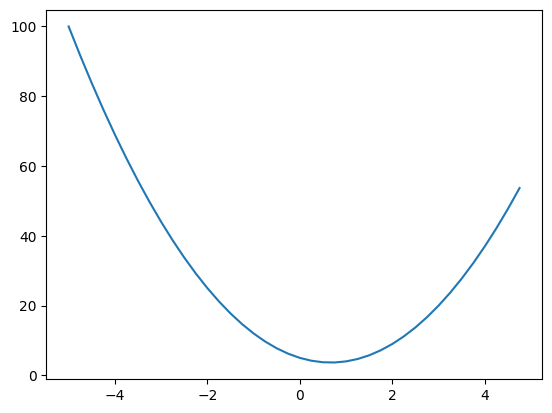

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [6]:
h = 0.0000001
x = -4
(f(x + h) - f(x)) / h

-27.999999616667992

In [7]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [8]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

c += h
d2 = a*b + c
print("d1", d1)
print("d2", d2)
print("gradient", (d2 - d1)/h)


d1 4.0
d2 4.0001
gradient 0.9999999999976694


In [100]:
class Value:

  def __init__(self, data, _children=(), _op="", label=""):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), "+")

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __radd__(self, other): # other + self
    return self + other

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __neg__(self):
    return -1 * self

  def __sub__(self, other):
    return self + (-other)


  def tanh(self):
    out = Value(np.tanh(self.data), (self, ), "tanh")

    def _backward():
      self.grad += (1 - np.tanh(self.data)**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), "exp")

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    topo

    self.grad = 1.0

    for node in reversed(topo):
      node._backward()


a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a*b
e.label = "e"
d = e + c
d.label = "d"
f = Value(-2.0)
f.label = "f"
L = d * f
L.label = "L"
L

Value(data=-8.0)

In [41]:
a = 4
a.__truediv__(2)
#having fun w dunder methods

b = Value(4)
c = Value(5.0)
b.exp() - c

Value(data=49.598150033144236)

In [10]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [11]:
d._op

'+'

In [12]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in grpah
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format = "svg", graph_attr = {"rankdir" : "LR"}) # LR is left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = '{%s | data %.4f | grad %.4f}' % (n.label, n.data, n.grad), shape = "record")
    if n._op:
      # if this value is the result of an operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node ot it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


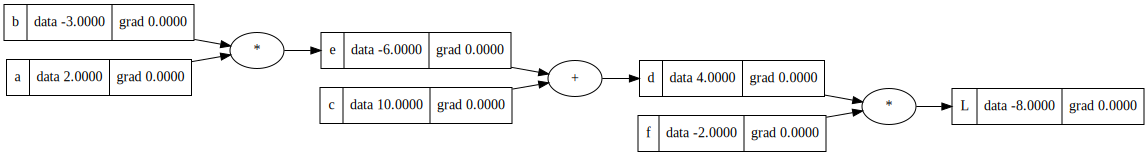

In [13]:
draw_dot(L)

In [14]:
L.grad = 1.0
d.grad = f.data
f.grad = d.data
e.grad = d.grad
c.grad = d.grad
a.grad = e.grad * b.data
b.grad = e.grad * a.data

In [15]:
def lol():
  a = Value(2.0, label="a")
  b = Value(-3.0, label="b")
  c = Value(10.0, label="c")
  e = a*b
  e.label = "e"
  d = e + c
  d.label = "d"
  f = Value(-2.0)
  f.label = "f"
  L = d * f
  L.label = "L"
  L1 = L.data

  h = 0.0001

  a = Value(2.0 , label="a")
  b = Value(-3.0, label="b")
  c = Value(10.0, label="c")
  e = a*b
  e.label = "e"
  d = e + c
  d.label = "d"
  f = Value(-2.0 + h)
  f.label = "f"
  L = d * f
  L.label = "L"
  L2 = L.data

  print((L2 - L1)/h)

lol()

3.9999999999995595


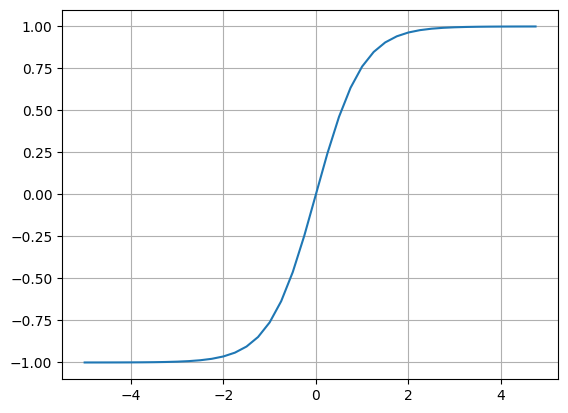

In [16]:
plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25)))
plt.grid()

In [27]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh()
o.label = "o"


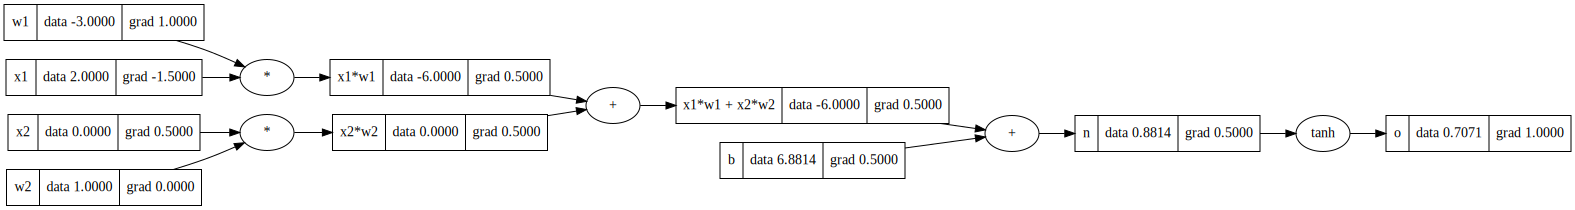

In [30]:
draw_dot(o)

In [29]:
o.backward()

In [21]:
o._backward()

In [22]:
n._backward()

In [23]:
x1w1x2w2._backward()

In [24]:
x1w1._backward()
x2w2._backward()

In [25]:
n.grad = 1/np.cosh(n.data)**2
b.grad = n.grad * 1
x1w1x2w2.grad = n.grad * 1
x1w1.grad = x1w1x2w2.grad * 1
x2w2.grad = x1w1x2w2.grad * 1
w2.grad = x2w2.grad * x2.data
x2.grad = x2w2.grad * w2.data
w1.grad = x1w1.grad * x1.data
x1.grad = x1w1.grad * w1.data

In [47]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

#-----
o = ((2*n).exp() - 1) / ((2*n).exp() + 1)
#------


o.label = "o"

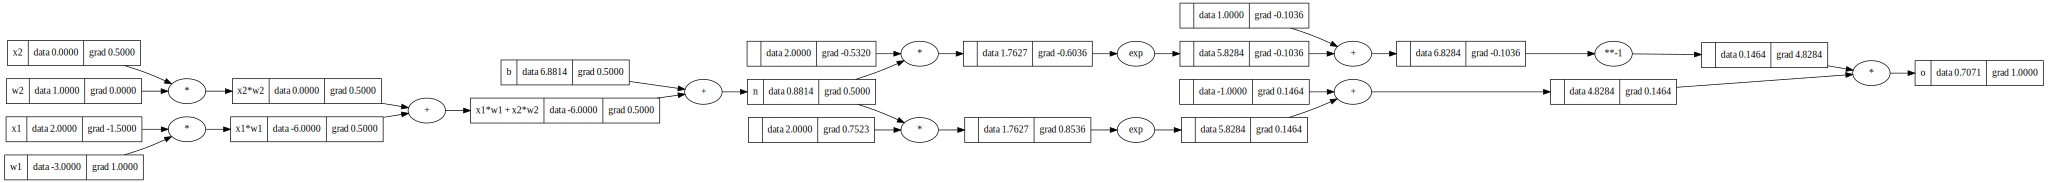

In [48]:
o.backward()

draw_dot(o)

In [50]:
import torch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [61]:
t = torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape
t

f = torch.Tensor([2])
f

f.data.item()

2.0

In [114]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(np.random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]



In [287]:
x = [1.0, 2.0, -3.0]
n = MLP(3, [4, 3, 1])

n(x)

Value(data=0.698096374071531)

In [251]:
n.parameters()

[Value(data=0.3015393581389958),
 Value(data=0.18130089067712274),
 Value(data=0.5115721805876403),
 Value(data=-0.04241576061212271),
 Value(data=0.1260068017337166),
 Value(data=-0.9880000650727907),
 Value(data=-0.24912458508800128),
 Value(data=0.3115193647706802),
 Value(data=-0.8707810438271895),
 Value(data=0.8026422684267853),
 Value(data=-0.8148216059511892),
 Value(data=-0.5786868811346637),
 Value(data=0.2516320208792424),
 Value(data=-0.6289961921153546),
 Value(data=0.48553607560786616),
 Value(data=0.240679869347888),
 Value(data=0.5989834679697648),
 Value(data=-0.4987292394508671),
 Value(data=0.5346956106821388),
 Value(data=0.5716790549843422),
 Value(data=0.13223192207682777),
 Value(data=0.8519039646074793),
 Value(data=-0.4305678620432225),
 Value(data=-0.6938516868834439),
 Value(data=-0.3463780966989003),
 Value(data=-0.25460577840340903),
 Value(data=0.2568006645010916),
 Value(data=0.6940111664757802),
 Value(data=-0.646524275965318),
 Value(data=0.081822082761

In [288]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets




In [289]:
for k in range(20):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  #backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  #gd
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 5.493232938600266
1 3.7714951456885366
2 2.7177359910954504
3 1.9118681693219992
4 1.3127866763818812
5 0.9161953472544951
6 0.6683367429267172
7 0.5109795939175346
8 0.4066195949545606
9 0.334147714579211
10 0.28167879268806434
11 0.24231935539149285
12 0.2119038230667859
13 0.1878085850685775
14 0.16831710125109872
15 0.15226764675797777
16 0.1388502527515618
17 0.12748527479132346
18 0.11774827757585514
19 0.10932212443749319
